In [9]:
pip install opencv-python


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


(-0.5, 203.5, 191.5, -0.5)

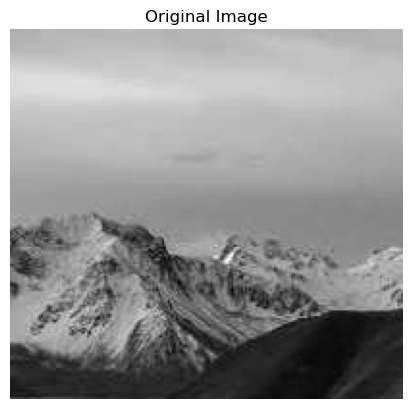

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy

# Load image
image = cv2.imread('asd.jpg', 0).astype(np.float32)

plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

In [12]:
def add_gaussian_noise(image, mean=0, std=20):
    noise = np.random.normal(mean, std, image.shape)
    noisy = image + noise
    return np.clip(noisy, 0, 255)

def add_rayleigh_noise(image, scale=1):
    noise = np.random.rayleigh(scale, image.shape)
    noisy = image + noise
    return np.clip(noisy, 0, 255)

def add_exponential_noise(image, scale=1):
    noise = np.random.exponential(scale, image.shape)
    noisy = image + noise
    return np.clip(noisy, 0, 255)

def add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    noisy = image.copy()

    num_salt = np.ceil(salt_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy[coords[0], coords[1]] = 255

    num_pepper = np.ceil(pepper_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy[coords[0], coords[1]] = 0

    return noisy

def add_uniform_noise(image, low=0, high=10):
    noise = np.random.uniform(low, high, image.shape)
    noisy = image + noise
    return np.clip(noisy, 0, 255)

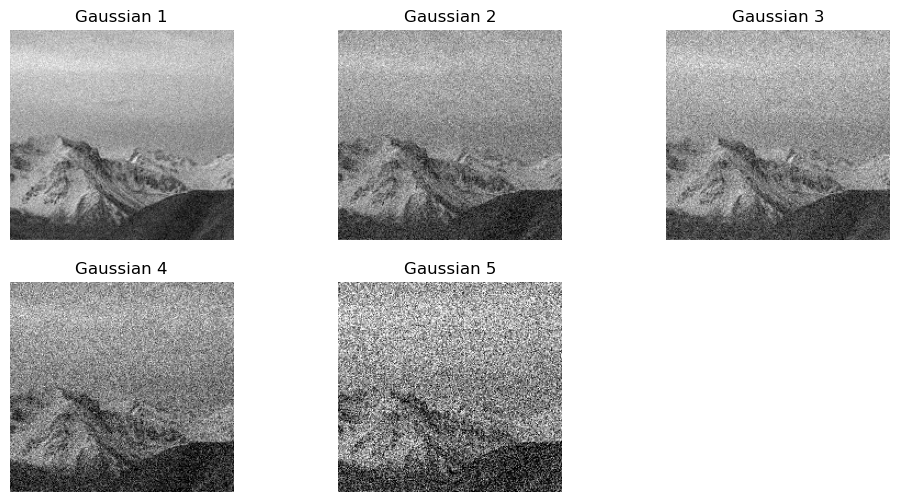

In [13]:
#TASK 1:
# Gaussian noise variations
gauss1 = add_gaussian_noise(image, 0, 10)
gauss2 = add_gaussian_noise(image, 0, 20)
gauss3 = add_gaussian_noise(image, 10, 20)
gauss4 = add_gaussian_noise(image, -10, 30)
gauss5 = add_gaussian_noise(image, 0, 50)

plt.figure(figsize=(12,6))
images = [gauss1, gauss2, gauss3, gauss4, gauss5]

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(f'Gaussian {i+1}')
    plt.axis('off')

plt.show()

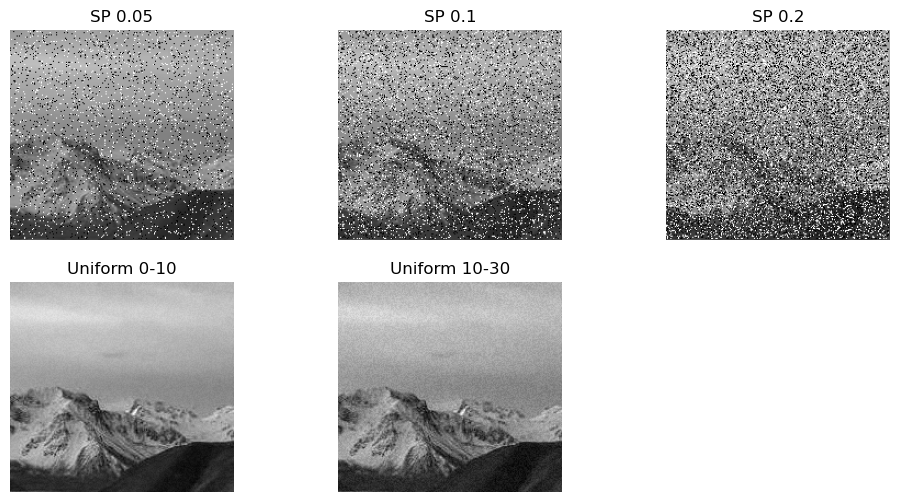

In [14]:
sp1 = add_salt_pepper_noise(image, 0.05, 0.05)
sp2 = add_salt_pepper_noise(image, 0.1, 0.1)
sp3 = add_salt_pepper_noise(image, 0.2, 0.2)

uniform1 = add_uniform_noise(image, 0, 10)
uniform2 = add_uniform_noise(image, 10, 30)

plt.figure(figsize=(12,6))

plt.subplot(2,3,1); plt.imshow(sp1, cmap='gray'); plt.title("SP 0.05")
plt.subplot(2,3,2); plt.imshow(sp2, cmap='gray'); plt.title("SP 0.1")
plt.subplot(2,3,3); plt.imshow(sp3, cmap='gray'); plt.title("SP 0.2")

plt.subplot(2,3,4); plt.imshow(uniform1, cmap='gray'); plt.title("Uniform 0-10")
plt.subplot(2,3,5); plt.imshow(uniform2, cmap='gray'); plt.title("Uniform 10-30")

for i in range(1,6):
    plt.subplot(2,3,i).axis('off')

plt.show()

In [15]:
def apply_filter(image, size, mode="mean", Q=1, d=0):
    pad = size // 2
    padded = np.pad(image, ((pad,pad),(pad,pad)), mode='symmetric')
    out = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i+size, j:j+size]

            if mode == "mean":
                out[i,j] = np.mean(patch)

            elif mode == "median":
                out[i,j] = np.median(patch)

            elif mode == "max":
                out[i,j] = np.max(patch)

            elif mode == "min":
                out[i,j] = np.min(patch)

            elif mode == "geometric":
                out[i,j] = np.exp(np.mean(np.log(patch + 1e-5)))

            elif mode == "harmonic":
                out[i,j] = patch.size / np.sum(1/(patch + 1e-5))

            elif mode == "contraharmonic":
                out[i,j] = np.sum(patch**(Q+1)) / (np.sum(patch**Q)+1e-5)

            elif mode == "alpha_trim":
                vals = np.sort(patch.flatten())
                trimmed = vals[d//2 : len(vals)-d//2]
                out[i,j] = np.mean(trimmed)

    return np.clip(out, 0, 255)

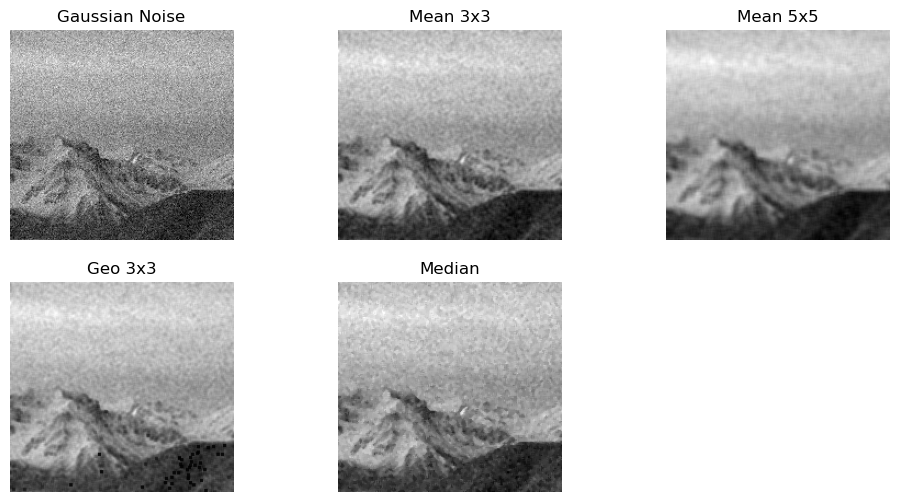

In [16]:
g_noise = add_gaussian_noise(image, 0, 20)

mean3 = apply_filter(g_noise, 3, "mean")
mean5 = apply_filter(g_noise, 5, "mean")

geo3 = apply_filter(g_noise, 3, "geometric")
geo5 = apply_filter(g_noise, 5, "geometric")

median3 = apply_filter(g_noise, 3, "median")

plt.figure(figsize=(12,6))

plt.subplot(2,3,1); plt.imshow(g_noise, cmap='gray'); plt.title("Gaussian Noise")
plt.subplot(2,3,2); plt.imshow(mean3, cmap='gray'); plt.title("Mean 3x3")
plt.subplot(2,3,3); plt.imshow(mean5, cmap='gray'); plt.title("Mean 5x5")
plt.subplot(2,3,4); plt.imshow(geo3, cmap='gray'); plt.title("Geo 3x3")
plt.subplot(2,3,5); plt.imshow(median3, cmap='gray'); plt.title("Median")

for i in range(1,6):
    plt.subplot(2,3,i).axis('off')

plt.show()

In [17]:
import cv2
import numpy as np

# -----------------------------

# -----------------------------
def salt_pepper_noise(image, ps, pp):
    noisy = image.copy()
    rand = np.random.rand(*image.shape[:2])

    # Salt
    noisy[rand < ps] = 255
    # Pepper
    noisy[rand > 1 - pp] = 0

    return noisy

# -----------------------------
def min_filter(img, k=5):
    return cv2.erode(img, np.ones((k, k), np.uint8))

def max_filter(img, k=5):
    return cv2.dilate(img, np.ones((k, k), np.uint8))

def harmonic_mean_filter(img, k=5):
    img = img.astype(np.float64) + 1e-6
    kernel = np.ones((k, k))
    denom = cv2.filter2D(1.0 / img, -1, kernel)
    return (k * k) / denom

def geometric_mean_filter(img, k=5):
    img = img.astype(np.float64) + 1e-6
    log_img = np.log(img)
    kernel = np.ones((k, k)) / (k * k)
    return np.exp(cv2.filter2D(log_img, -1, kernel))

def contraharmonic_filter(img, k=5, Q=1):
    img = img.astype(np.float64) + 1e-6
    num = cv2.filter2D(np.power(img, Q + 1), -1, np.ones((k, k)))
    den = cv2.filter2D(np.power(img, Q), -1, np.ones((k, k)))
    return num / den

# -----------------------------

# -----------------------------
img = cv2.imread('asd.jpg', 0)


# -----------------------------
n1 = salt_pepper_noise(img, 0.1, 0.1)

min1 = min_filter(n1)
max1 = max_filter(n1)
harm1 = harmonic_mean_filter(n1)
geo1 = geometric_mean_filter(n1)


# -----------------------------
n2 = salt_pepper_noise(img, 0.2, 0)

min2 = min_filter(n2)
contra_neg2 = contraharmonic_filter(n2, Q=-2)
harm2 = harmonic_mean_filter(n2)


# -----------------------------
n3 = salt_pepper_noise(img, 0, 0.2)

max3 = max_filter(n3)
contra_pos2 = contraharmonic_filter(n3, Q=2)

# -----------------------------

# -----------------------------
cv2.imwrite('n1.png', n1)
cv2.imwrite('min1.png', min1)
cv2.imwrite('max1.png', max1)
cv2.imwrite('harm1.png', harm1)
cv2.imwrite('geo1.png', geo1)

cv2.imwrite('n2.png', n2)
cv2.imwrite('min2.png', min2)
cv2.imwrite('contra_neg2.png', contra_neg2)
cv2.imwrite('harm2.png', harm2)

cv2.imwrite('n3.png', n3)
cv2.imwrite('max3.png', max3)
cv2.imwrite('contra_pos2.png', contra_pos2)

[ WARN:0@1425.347] global loadsave.cpp:848 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


True